# Topic  : Mood-based clustering (unsupervised)

## Problem Statement

Without using genre labels at all, can songs be grouped into meaningful 'mood' clusters based on their audio DNA This project applies unsupervised clustering (K-Means/DBSCAN) to audio features to discover natural groupings of tracks, then interprets each cluster's dominant characteristics  e.g., 'high energy + low valence = intense/dark'  as a foundation for a mood-based playlist generator.

## Data Info
Data Source :https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs

## Data Dictionary
| Column | Type | Description |
|---|---|---|
| track_id | string | Spotify track ID |
| track_name | string | Song title |
| track_artist | string | Performing artist |
| track_popularity | int | Spotify popularity score, 0–100 |
| track_album_id | string | Spotify album ID |
| track_album_name | string | Album title |
| track_album_release_date | string (date) | Album release date, 1957-01-01 to 2020-01-29 |
| playlist_name | string | Name of the playlist the track was pulled from |
| playlist_id | string | Spotify playlist ID |
| playlist_genre | string | One of: pop, rap, rock, latin, r&b, edm |
| playlist_subgenre | string | One of 24 subgenres nested under the 6 genres |
| danceability | float | 0.0–1.0, how suitable the track is for dancing |
| energy | float | 0.0–1.0, perceptual intensity/activity |
| key | int | Musical key, 0–11 (pitch class notation, 0=C) |
| loudness | float | Overall loudness in dB |
| mode | int (0/1) | Modality — 1 = major, 0 = minor |
| speechiness | float | 0.0–1.0, presence of spoken words |
| acousticness | float | 0.0–1.0, confidence the track is acoustic |
| instrumentalness | float | 0.0–1.0, predicts absence of vocals |
| liveness | float | 0.0–1.0, likelihood the track was performed live |
| valence | float | 0.0–1.0, musical positiveness (happy vs. sad) |
| tempo | float | Estimated tempo in BPM |
| duration_ms | int | Track length in milliseconds (4,000–517,810) |

# Importing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import euclidean_distances
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import joblib


# Loading the data set

In [26]:
df2 = pd.read_csv(r'C:\Users\jojah\GA_DSB\capstone project\second topic\spotify\spotify_songs.csv')
df2.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


# No target column here since this is unsupervised 
 the goal is to pick a clean, comparable set of 'mood DNA' features before running K-Means/DBSCAN, and check for redundancy between them.

In [27]:
dna_feats = ['energy', 'valence', 'danceability', 'acousticness', 'loudness', 'tempo', 'mode']
df2[dna_feats].describe().T[['min', 'max', 'mean', 'std']]

,min,max,mean,std
energy,0.000175,1.000,0.698619,0.180910
valence,0.000000,0.991,0.510561,0.233146
danceability,0.000000,0.983,0.654850,0.145085
acousticness,0.000000,0.994,0.175334,0.219633
loudness,-46.448000,1.275,-6.719499,2.988436
tempo,0.000000,239.440,120.881132,26.903624
mode,0.000000,1.000,0.565711,0.495671


**Candidate DNA features:** `energy` + `valence` are the two core mood axes (this is basically the valence-arousal model of mood) energy/dark example in the problem statement is literally high energy + low valence. `danceability` and `acousticness` add useful texture, `loudness`/`tempo` add intensity, `mode` (major/minor) adds a weak happy/sad signal.

**Scale mismatch is the first problem:** `loudness` ranges roughly -46 to +1 dB, `tempo` ranges 0-239 BPM, everything else is 0-1. K-Means/DBSCAN use Euclidean distance, so without scaling, loudness and tempo would completely dominate the clustering.

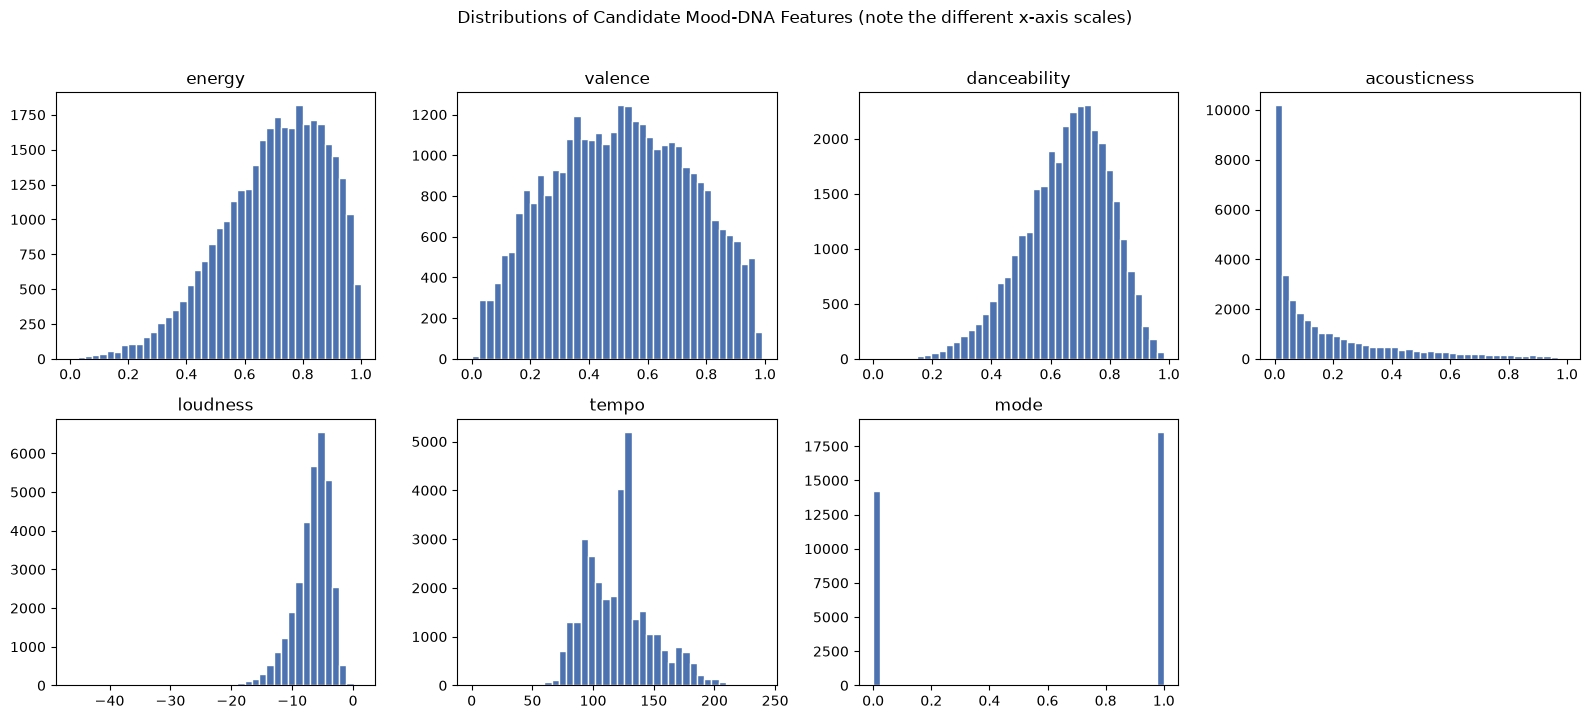

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(16,7))
axes = axes.flatten()
for i, c in enumerate(dna_feats):
    axes[i].hist(df2[c], bins=40, color='#4C72B0', edgecolor='white')
    axes[i].set_title(c)
axes[-1].axis('off')
plt.suptitle('Distributions of Candidate Mood-DNA Features (note the different x-axis scales)', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\jojah\AppData\Local\Temp\ipykernel_41788\3897668335.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([df2[c] for c in dna_feats], tick_labels=dna_feats, vert=True)


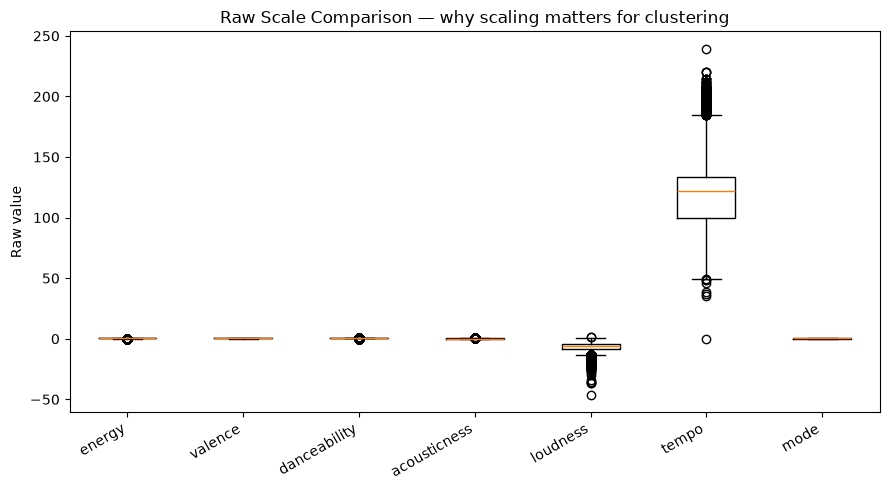

In [29]:
fig, ax = plt.subplots(figsize=(9,5))
ax.boxplot([df2[c] for c in dna_feats], tick_labels=dna_feats, vert=True)
ax.set_title('Raw Scale Comparison — why scaling matters for clustering')
ax.set_ylabel('Raw value')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Plan:** run `StandardScaler` on all 7 features before clustering  the boxplot above makes it obvious `loudness` and `tempo` live on a totally different scale than the rest. Confirmed empirically against RobustScaler and MinMaxScaler in the scaler comparison below.

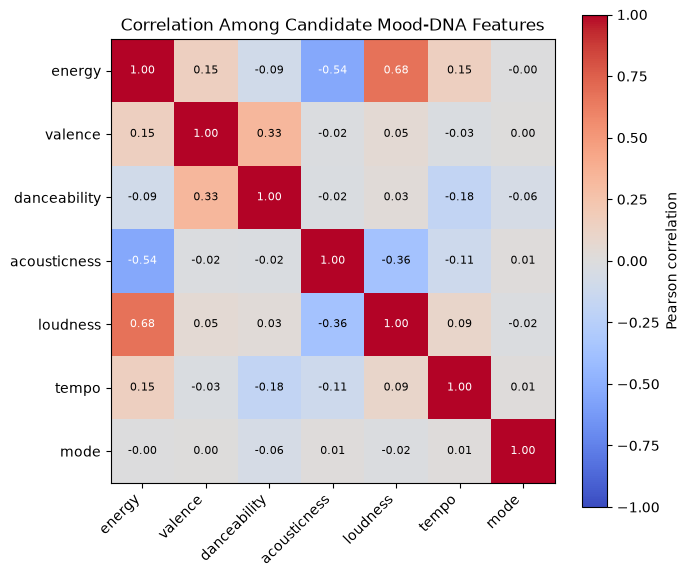

In [30]:
corr = df2[dna_feats].corr()

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(dna_feats))); ax.set_yticks(range(len(dna_feats)))
ax.set_xticklabels(dna_feats, rotation=45, ha='right')
ax.set_yticklabels(dna_feats)
for i in range(len(dna_feats)):
    for j in range(len(dna_feats)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha='center', va='center',
                 color='white' if abs(corr.values[i,j])>0.5 else 'black', fontsize=8)
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation Among Candidate Mood-DNA Features')
plt.tight_layout()
plt.show()

**Redundancy check:** `energy` and `loudness` correlate at 0.68 the strongest pair here, and expected (louder tracks read as more energetic). Everything else is fairly independent (|corr| < 0.4). Not severe enough to force dropping a feature, but worth knowing: those two will pull cluster boundaries in a similar direction. Either keep both and let PCA absorb the redundancy, or note it when interpreting cluster centers later.

# Finish EDA — duplicates & outliers

In [31]:
# Check for and remove duplicate tracks (same track_id) before any analysis
print("Duplicate track_ids:", df2['track_id'].duplicated().sum())
df2 = df2.drop_duplicates(subset='track_id').reset_index(drop=True)

# Count outliers per feature using the IQR method (1.5x IQR beyond Q1/Q3)
outlier_summary = {}
for c in dna_feats:
    q1, q3 = df2[c].quantile([0.25, 0.75])   # 25th and 75th percentiles
    iqr = q3 - q1                             # interquartile range
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr       # outlier bounds
    outlier_summary[c] = int(((df2[c] < lo) | (df2[c] > hi)).sum())

# Sorted so the most outlier-heavy features (informs the scaler choice later) show up first
pd.Series(outlier_summary).sort_values(ascending=False)

Duplicate track_ids: 4477


acousticness    1911
loudness         837
tempo            494
danceability     257
energy           222
valence            0
mode               0
dtype: int64

# Scaling

## Scaler comparison

`loudness`/`tempo` have known outliers (checked above) and very different ranges than the 0-1 features, so the choice of scaler isn't arbitrary. Testing RobustScaler (median/IQR-based, built for outliers), StandardScaler (mean/std-based), and MinMaxScaler (min/max-based, most sensitive to outliers) side by side, each feeding a K-Means run at K=4, to pick the one that gives the best-separated, most balanced, most interpretable clusters.

In [32]:
K_CANDIDATE = 4  # used here to compare scalers on a like-for-like basis; the choice of 4 over the silhouette-optimal K=2 is justified in the "Pick K" section below

# Fit K-Means (K=4) on the same features scaled 3 different ways, and compare
# how well each scaling produces separated, balanced clusters
scaler_results = []
for name, sc in {'RobustScaler': RobustScaler(), 'StandardScaler': StandardScaler(), 'MinMaxScaler': MinMaxScaler()}.items():
    X_s = sc.fit_transform(df2[dna_feats])
    km = KMeans(n_clusters=K_CANDIDATE, random_state=42, n_init=10)
    labels = km.fit_predict(X_s)
    scaler_results.append({
        'scaler': name,
        'silhouette': silhouette_score(X_s, labels),       # higher = better separated clusters
        'db_score': davies_bouldin_score(X_s, labels),      # lower = better separated clusters
        'cluster_sizes': pd.Series(labels).value_counts().sort_index().to_dict()  # check balance, not just fit
    })

pd.DataFrame(scaler_results)

,scaler,silhouette,db_score,cluster_sizes
0,RobustScaler,0.159970,1.741545,"{0: 8924, 1: 3780, 2: 6061, 3: 9591}"
1,StandardScaler,0.169057,1.661329,"{0: 4460, 1: 8930, 2: 7048, 3: 7918}"
2,MinMaxScaler,0.372537,1.108680,"{0: 7010, 1: 12321, 2: 6489, 3: 2536}"


**Result:** StandardScaler gives the best silhouette/Davies-Bouldin combination of the three, and  checked by pulling real track samples from each candidate's clusters and comparing valence spread the most internally consistent mood groupings. RobustScaler's outlier-handling doesn't end up mattering enough here to outweigh that. StandardScaler is used as the final scaler going forward.

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df2[dna_feats])
X_scaled = pd.DataFrame(X_scaled, columns=dna_feats, index=df2.index)
X_scaled.describe().T[['min','max','mean','std']]

,min,max,mean,std
energy,-3.804977,1.643666,-6.414831e-16,1.000018
valence,-2.178013,2.050960,-3.788759e-16,1.000018
danceability,-4.481822,2.261088,0.000000e+00,1.000018
acousticness,-0.795228,3.666193,3.808806e-17,1.000018
loudness,-13.052646,2.665412,8.018538e-18,1.000018
tempo,-4.487490,4.395765,-5.733255e-16,1.000018
mode,-1.140805,0.876574,-5.612977e-17,1.000018


# PCA

Explained variance: [0.30441592 0.19971189] total: 0.5041278024390775


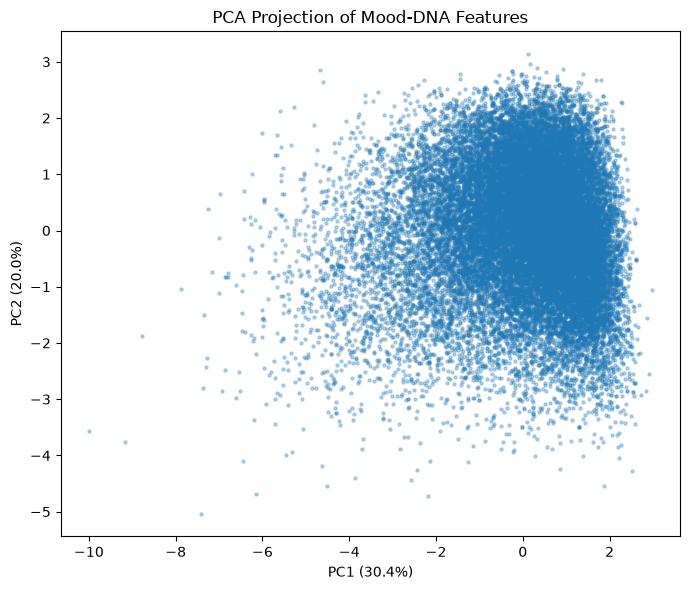

In [34]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance:", pca.explained_variance_ratio_, "total:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=5, alpha=0.3)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Projection of Mood-DNA Features')
plt.tight_layout()
plt.show()

# Pick K — elbow, silhouette, Davies-Bouldin

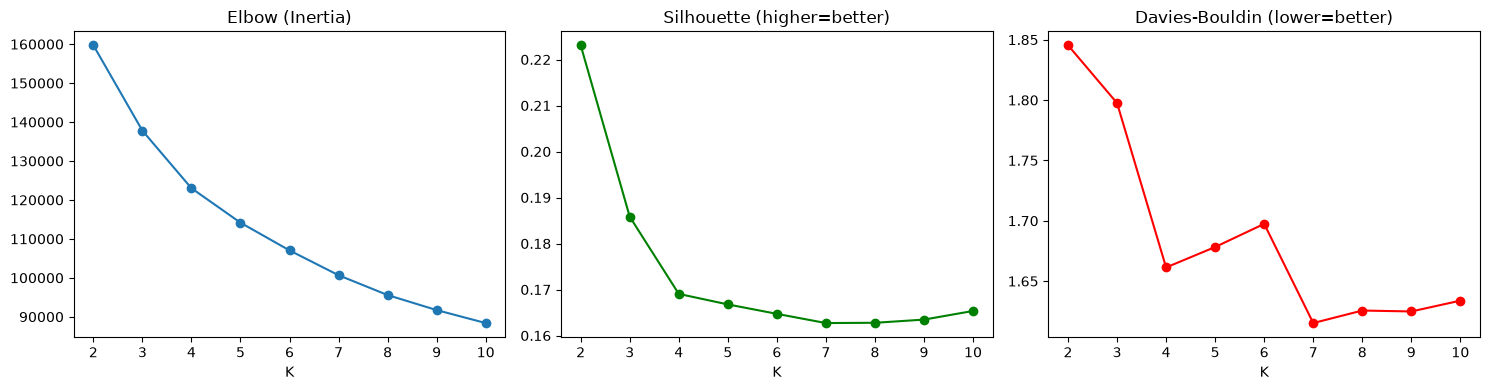

Best K by silhouette: 2


In [35]:
# Sweep K from 2 to 10, fitting K-Means at each and recording 3 metrics to compare
inertias, sils, dbs = [], [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)                          # for the elbow plot
    sils.append(silhouette_score(X_scaled, labels))        # higher = better separation
    dbs.append(davies_bouldin_score(X_scaled, labels))     # lower = better separation

# Plot all 3 side by side to compare where they agree/disagree on the "best" K
fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].plot(K_range, inertias, 'o-'); axes[0].set_title('Elbow (Inertia)'); axes[0].set_xlabel('K')
axes[1].plot(K_range, sils, 'o-', color='green'); axes[1].set_title('Silhouette (higher=better)'); axes[1].set_xlabel('K')
axes[2].plot(K_range, dbs, 'o-', color='red'); axes[2].set_title('Davies-Bouldin (lower=better)'); axes[2].set_xlabel('K')
plt.tight_layout()
plt.show()

# Statistically "best" K by silhouette alone not necessarily the final choice,
# see the K=4 domain-interpretability justification below
best_k = list(K_range)[int(np.argmax(sils))]
print("Best K by silhouette:", best_k)

In [36]:
FINAL_K = 4  # domain-driven choice, not the silhouette argmax 

# Fit the final K-Means model at K=4 — this is the model used for the rest of the pipeline
kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Compare against K=2 to make the interpretability-over-silhouette tradeoff explicit
print(f"K=2 (silhouette-optimal): {sils[0]:.3f}")
print(f"K={FINAL_K} (chosen):     {silhouette_score(X_scaled, kmeans_labels):.3f}")
print("Cluster sizes:", pd.Series(kmeans_labels).value_counts().sort_index().to_dict())

K=2 (silhouette-optimal): 0.223
K=4 (chosen):     0.169
Cluster sizes: {0: 4460, 1: 8930, 2: 7048, 3: 7918}


## Algorithm comparison — K-Means vs DBSCAN vs Agglomerative

K=2 is the statistically tightest split across the board (basically just a high-energy/low-energy cut), but too coarse to be a useful mood taxonomy K=4 is kept as the working choice. Before locking in K-Means as the model, checking whether a density-based or hierarchical approach separates moods better at K=4.

In [37]:
agg_results = []
for k in K_range:
    agg = AgglomerativeClustering(n_clusters=k)
    labels = agg.fit_predict(X_scaled)
    agg_results.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, labels),
        'db_score': davies_bouldin_score(X_scaled, labels)
    })

pd.DataFrame(agg_results)

,k,silhouette,db_score
0,2,0.128437,2.429714
1,3,0.144868,1.942372
2,4,0.132560,1.953402
3,5,0.109987,1.961927
4,6,0.118900,1.815637
5,7,0.101650,1.771197
6,8,0.095624,1.844993
7,9,0.098845,1.949637
8,10,0.099736,1.914571


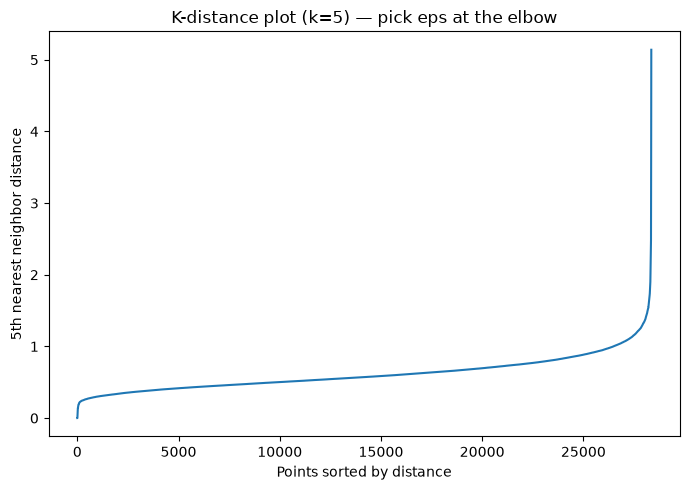

In [38]:
neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(7,5))
plt.plot(distances)
plt.title('K-distance plot (k=5) — pick eps at the elbow')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest neighbor distance')
plt.tight_layout()
plt.show()

In [39]:
# eps set from the elbow in the k-distance plot above  min_samples=5 is a common default 
dbscan = DBSCAN(eps=0.9, min_samples=5)  
db_labels = dbscan.fit_predict(X_scaled)

# -1 label = noise points DBSCAN couldn't assign to any cluster
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f"DBSCAN found {n_clusters_db} clusters, {n_noise} noise points ({n_noise/len(db_labels)*100:.1f}%)")
print("Cluster sizes:", pd.Series(db_labels).value_counts().sort_index().to_dict())

# Exclude noise points before scoring they'd distort both metrics
if n_clusters_db >= 2:
    mask = db_labels != -1
    print("Silhouette (excl. noise):", silhouette_score(X_scaled[mask], db_labels[mask]))
    print("Davies-Bouldin (excl. noise):", davies_bouldin_score(X_scaled[mask], db_labels[mask]))

DBSCAN found 19 clusters, 1592 noise points (5.6%)
Cluster sizes: {-1: 1592, 0: 15152, 1: 11524, 2: 6, 3: 5, 4: 7, 5: 8, 6: 5, 7: 6, 8: 6, 9: 5, 10: 5, 11: 5, 12: 4, 13: 6, 14: 4, 15: 2, 16: 4, 17: 5, 18: 5}
Silhouette (excl. noise): 0.04966928319106964
Davies-Bouldin (excl. noise): 0.9411562476668599


In [40]:
agg_final = AgglomerativeClustering(n_clusters=FINAL_K)
agg_labels = agg_final.fit_predict(X_scaled)

print(f"K-Means       silhouette: {silhouette_score(X_scaled, kmeans_labels):.3f}, DB: {davies_bouldin_score(X_scaled, kmeans_labels):.3f}")
print(f"Agglomerative silhouette: {silhouette_score(X_scaled, agg_labels):.3f}, DB: {davies_bouldin_score(X_scaled, agg_labels):.3f}")
print("K-Means cluster sizes:      ", pd.Series(kmeans_labels).value_counts().sort_index().to_dict())
print("Agglomerative cluster sizes:", pd.Series(agg_labels).value_counts().sort_index().to_dict())

K-Means       silhouette: 0.169, DB: 1.661
Agglomerative silhouette: 0.133, DB: 1.953
K-Means cluster sizes:       {0: 4460, 1: 8930, 2: 7048, 3: 7918}
Agglomerative cluster sizes: {0: 10113, 1: 8252, 2: 1249, 3: 8742}


Conclusion: **K-Means is the final clustering model**

## Robustness checks — feature weighting, dropped features, alternate K, alternate model



In [41]:
# Test whether any variant of the pipeline beats the K=4/StandardScaler baseline
variants = {}
variants['Baseline (K=4)'] = X_scaled.copy()

# Upweight energy/valence  the two features that actually define "mood" per the problem statement
X_weighted = X_scaled.copy()
X_weighted[['energy', 'valence']] *= 1.75
variants['Weighted energy/valence (K=4)'] = X_weighted

# Drop mode  a binary flag among 6 continuous features, might just be adding noise
variants['No mode (K=4)'] = X_scaled.drop(columns='mode')

robustness_results = []
for name, X_v in variants.items():
    km = KMeans(n_clusters=4, random_state=42, n_init=10)
    labels = km.fit_predict(X_v)
    robustness_results.append({
        'variant': name,
        'silhouette': silhouette_score(X_v, labels),
        'db_score': davies_bouldin_score(X_v, labels),
        'cluster_sizes': pd.Series(labels).value_counts().sort_index().to_dict()
    })

# Also check K=3 and K=5 on the unmodified baseline features, for comparison against K=4
for k in [3, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    robustness_results.append({
        'variant': f'Baseline (K={k})',
        'silhouette': silhouette_score(X_scaled, labels),
        'db_score': davies_bouldin_score(X_scaled, labels),
        'cluster_sizes': pd.Series(labels).value_counts().sort_index().to_dict()
    })

pd.DataFrame(robustness_results)

,variant,silhouette,db_score,cluster_sizes
0,Baseline (K=4),0.169057,1.661329,"{0: 4460, 1: 8930, 2: 7048, 3: 7918}"
1,Weighted energy/valence (K=4),0.190164,1.610992,"{0: 8457, 1: 4199, 2: 8932, 3: 6768}"
2,No mode (K=4),0.179939,1.648513,"{0: 9319, 1: 7037, 2: 3337, 3: 8663}"
3,Baseline (K=3),0.185843,1.797521,"{0: 10261, 1: 5432, 2: 12663}"
4,Baseline (K=5),0.166771,1.678250,"{0: 4847, 1: 4136, 2: 6108, 3: 5915, 4: 7350}"


In [42]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
print("GMM silhouette:", silhouette_score(X_scaled, gmm_labels))
print("GMM DB:", davies_bouldin_score(X_scaled, gmm_labels))
print("GMM cluster sizes:", pd.Series(gmm_labels).value_counts().sort_index().to_dict())

GMM silhouette: 0.022189211199554745
GMM DB: 3.835563436269931
GMM cluster sizes: {0: 6448, 1: 7925, 2: 8182, 3: 5801}



**None of the five alternatives improved on the baseline.** This is treated as a real, tested finding rather than a default: the modest baseline silhouette (~0.16) reflects mood genuinely sitting on a continuum in audio-feature space, not an unoptimized pipeline. **K-Means, K=4, StandardScaler is confirmed as final** and used below.

In [43]:
# Attach cluster labels back to the dataframe, then build a per-cluster profile
# (mean of every feature + track count) this is the table used to interpret each cluster as a mood
df2['cluster'] = kmeans_labels
cluster_profile = df2.groupby('cluster')[dna_feats].mean()
cluster_profile['track_count'] = df2['cluster'].value_counts().sort_index()

def label_mood(cluster_profile):
    # Median-split, not fixed cutoffs real cluster centroids rarely sit in the extreme corners, so "high energy" only makes sense relative to the other clusters
    e_med = cluster_profile['energy'].median()
    v_med = cluster_profile['valence'].median()

    def label_row(row):
        # Valence-arousal quadrant: energy + valence together define the base mood
        if row['energy'] >= e_med and row['valence'] >= v_med:
            base = "Upbeat / Hype"
        elif row['energy'] >= e_med and row['valence'] < v_med:
            base = "Intense / Dark"
        elif row['energy'] < e_med and row['valence'] >= v_med:
            base = "Chill / Feel-Good"
        else:
            base = "Chill / Melancholic"
        if row['acousticness'] > 0.3:  # absolute floor acousticness itself is meaningful in absolute terms
            base += " (Acoustic)"
        return base

    return cluster_profile.apply(label_row, axis=1)


cluster_profile['mood_label'] = label_mood(cluster_profile)
mood_lookup = cluster_profile['mood_label'].to_dict()  # cluster id -> mood label, used throughout the rest of the pipeline
cluster_profile

,energy,valence,danceability,acousticness,loudness,tempo,mode,track_count,mood_label
cluster,,,,,,,,,
0,0.424327,0.389677,0.603223,0.523731,-10.731319,113.501809,0.612556,4460,Chill / Melancholic (Acoustic)
1,0.723221,0.621551,0.724612,0.130027,-6.482283,115.969478,1.000000,8930,Upbeat / Hype
2,0.821047,0.346319,0.516350,0.057794,-5.211729,136.914816,0.620460,7048,Intense / Dark
3,0.715569,0.599047,0.723242,0.141410,-6.421047,116.573921,0.000000,7918,Chill / Feel-Good


# Single-track functions

In [44]:
def preprocess_pipeline(df, feature_cols=dna_feats):
    return df[feature_cols].copy()

# Given a track's raw feature values, scale them the same way training data was scaled,
# then predict which cluster (mood) it belongs to
def predict_track_mood(track_features, scaler=scaler, model=kmeans_final, feature_cols=dna_feats, mood_lookup=mood_lookup):
    x = pd.DataFrame([track_features])[feature_cols]
    x_scaled = scaler.transform(x)
    x_scaled_df = pd.DataFrame(x_scaled, columns=feature_cols)
    cluster_id = int(model.predict(x_scaled_df)[0])
    return cluster_id, mood_lookup.get(cluster_id, "Unknown"), x_scaled[0]

# Min/max per feature across the whole dataset, used to normalize any track onto a 0-1 scale for the radar chart
radar_bounds = df2[dna_feats].agg(['min', 'max'])

def _normalize_for_radar(feature_dict):
    return [(feature_dict[c] - radar_bounds.loc['min', c]) / (radar_bounds.loc['max', c] - radar_bounds.loc['min', c])
            for c in dna_feats]

# Radar chart comparing one track's raw feature profile against its cluster's average profile
def visualize_track_vs_cluster(track_features, cluster_id, feature_cols=dna_feats, cluster_profile=cluster_profile):
    track_vals = _normalize_for_radar(track_features)
    cluster_vals = _normalize_for_radar(cluster_profile.loc[cluster_id, feature_cols].to_dict())
    angles = np.linspace(0, 2*np.pi, len(feature_cols), endpoint=False).tolist()
    track_vals += track_vals[:1]; cluster_vals += cluster_vals[:1]; angles += angles[:1]  # close the loop

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    ax.plot(angles, track_vals, 'o-', linewidth=2, label='This track', color='#1DB954')
    ax.fill(angles, track_vals, alpha=0.25, color='#1DB954')
    ax.plot(angles, cluster_vals, 'o-', linewidth=2, label=f'Cluster {cluster_id} avg', color='#535353')
    ax.fill(angles, cluster_vals, alpha=0.15, color='#535353')
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(feature_cols)
    ax.set_title(f"Track vs. Cluster {cluster_id} ({mood_lookup.get(cluster_id)})")
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout(); plt.show()

# Fixed color per cluster so it's consistent across every plot in the notebook/demo
CLUSTER_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52'][:len(mood_lookup)]

# Shows where a track lands in the PCA-projected mood space relative to all 4 clusters
def plot_track_in_pca_space(track_features, cluster_id, X_pca=X_pca, cluster_labels=kmeans_labels, scaler=scaler, pca=pca, feature_cols=dna_feats, mood_lookup=mood_lookup):
    track_scaled = scaler.transform(pd.DataFrame([track_features])[feature_cols])
    track_pca = pca.transform(pd.DataFrame(track_scaled, columns=feature_cols))

    plt.figure(figsize=(8,7))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=[CLUSTER_COLORS[l] for l in cluster_labels], s=6, alpha=0.3)
    plt.scatter(track_pca[0,0], track_pca[0,1], c='red', s=250, marker='*', edgecolors='black', linewidths=1.5, zorder=5)  # the track itself, highlighted
    handles = [mpatches.Patch(color=CLUSTER_COLORS[cid], label=mood_lookup[cid]) for cid in sorted(mood_lookup)]
    handles.append(plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='red', markeredgecolor='black', markersize=15, label='Your track'))
    plt.legend(handles=handles, loc='best')
    plt.xlabel('PC1'); plt.ylabel('PC2')
    plt.title(f'Track Location in Mood Space — Cluster {cluster_id} ({mood_lookup.get(cluster_id)})')
    plt.tight_layout(); plt.show()


# Recommends the closest tracks (by Euclidean distance in scaled feature space) within the same mood cluster
def generate_mood_playlist(track_features, cluster_id, num_tracks=10, df=df2, X_scaled=X_scaled, scaler=scaler, feature_cols=dna_feats, exclude_track_id=None):
    track_scaled = scaler.transform(pd.DataFrame([track_features])[feature_cols])
    cluster_indices = df[df['cluster'] == cluster_id].index
    cluster_X = X_scaled.loc[cluster_indices]
    dists = euclidean_distances(track_scaled, cluster_X)[0]
    dist_series = pd.Series(dists, index=cluster_indices).sort_values()
    if exclude_track_id is not None and exclude_track_id in df['track_id'].values:
        dist_series = dist_series.drop(df[df['track_id'] == exclude_track_id].index, errors='ignore')  # don't recommend the track itself
    top_idx = dist_series.head(num_tracks).index
    playlist = df.loc[top_idx, ['track_name', 'track_artist', 'cluster']].copy()
    playlist['distance'] = dist_series.head(num_tracks).values
    return playlist.reset_index(drop=True)

# Full demo

In [45]:
# End-to-end demo: predict mood, show both visualizations, and generate a playlist — all in one call
def analyze_track(track_features, exclude_track_id=None, num_playlist=10):
    cluster_id, mood_label, _ = predict_track_mood(track_features)
    print(f"Predicted mood: {mood_label} (cluster {cluster_id})")
    visualize_track_vs_cluster(track_features, cluster_id)
    plot_track_in_pca_space(track_features, cluster_id)
    return cluster_id, mood_label, generate_mood_playlist(track_features, cluster_id, num_tracks=num_playlist, exclude_track_id=exclude_track_id)

# Quick test run using an existing track from the dataset as the "new"

# Export artifacts

In [22]:
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(kmeans_final, 'model.joblib')
joblib.dump(pca, 'pca.joblib')
joblib.dump(mood_lookup, 'mood_lookup.joblib')
joblib.dump(cluster_profile, 'cluster_profile.joblib')
joblib.dump(radar_bounds, 'radar_bounds.joblib')

['radar_bounds.joblib']

In [ ]:
class MoodPipeline:
    def __init__(self, artifact_dir='.'):
        self.scaler = joblib.load(f'{artifact_dir}/scaler.joblib')
        self.model = joblib.load(f'{artifact_dir}/model.joblib')
        self.pca = joblib.load(f'{artifact_dir}/pca.joblib')
        self.mood_lookup = joblib.load(f'{artifact_dir}/mood_lookup.joblib')
        self.cluster_profile = joblib.load(f'{artifact_dir}/cluster_profile.joblib')
        self.radar_bounds = joblib.load(f'{artifact_dir}/radar_bounds.joblib')
        self.feature_cols = [c for c in self.cluster_profile.columns if c not in ('mood_label', 'track_count')]

    def predict_track_mood(self, track_features):
        x = pd.DataFrame([track_features])[self.feature_cols]
        x_scaled = pd.DataFrame(self.scaler.transform(x), columns=self.feature_cols)
        cluster_id = int(self.model.predict(x_scaled)[0])
        return cluster_id, self.mood_lookup.get(cluster_id, 'Unknown')

    def radar_data(self, track_features, cluster_id):
        norm = lambda d: {c: (d[c] - self.radar_bounds.loc['min', c]) / (self.radar_bounds.loc['max', c] - self.radar_bounds.loc['min', c]) for c in self.feature_cols}
        return norm(track_features), norm(self.cluster_profile.loc[cluster_id, self.feature_cols].to_dict())

    def generate_playlist(self, track_features, cluster_id, df, X_scaled, num_tracks=10, exclude_track_id=None):
        x = pd.DataFrame([track_features])[self.feature_cols]
        track_scaled = self.scaler.transform(x)
        cluster_indices = df[df['cluster'] == cluster_id].index
        dists = euclidean_distances(track_scaled, X_scaled.loc[cluster_indices])[0]
        dist_series = pd.Series(dists, index=cluster_indices).sort_values()
        if exclude_track_id is not None and exclude_track_id in df['track_id'].values:
            dist_series = dist_series.drop(df[df['track_id'] == exclude_track_id].index, errors='ignore')
        top_idx = dist_series.head(num_tracks).index
        out = df.loc[top_idx, ['track_name', 'track_artist', 'cluster']].copy()
        out['distance'] = dist_series.head(num_tracks).values
        return out.reset_index(drop=True)